# 08. Model Improvement

Goal: I want to understand why my baseline model is weak, then improve it step by step.

In this notebook I first compare train and test performance. That tells me whether my model is overfitting, underfitting, or actually generalizing well.

## 1. Import Libraries

In [44]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load Cleaned Dataset

I am using the cleaned dataset here because model improvement should come after the basic cleaning work is already done.

In [45]:
df = pd.read_csv("../data/processed/cleaned_salary_data.csv")

print(df.shape)
df.head()

(565, 9)


,work_year,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size,salary_in_usd
0,2020,MI,FT,Data Scientist,DE,0,DE,L,79833
1,2020,SE,FT,Machine Learning Scientist,JP,0,JP,S,260000
2,2020,SE,FT,Big Data Engineer,GB,50,GB,M,109024
3,2020,MI,FT,Product Data Analyst,HN,0,HN,S,20000
4,2020,SE,FT,Machine Learning Engineer,US,50,US,L,150000


## 3. Separate Features and Target

`X` contains the input columns.

`y` contains the target column I want to predict: `salary_in_usd`.

In [46]:
X = df.drop(columns=["salary_in_usd"])
y = df["salary_in_usd"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (565, 8)
y shape: (565,)


## 4. Define Preprocessing Columns

Numeric columns are scaled.

Categorical columns are one-hot encoded.

In [47]:
numeric_columns = [
    "work_year",
    "remote_ratio"
]

categorical_columns = [
    "experience_level",
    "employment_type",
    "job_title",
    "employee_residence",
    "company_location",
    "company_size"
]

handled_columns = numeric_columns + categorical_columns
unhandled_columns = sorted(set(X.columns) - set(handled_columns))

print(f"Unhandled columns: {unhandled_columns}")

if unhandled_columns:
    raise ValueError(f"These columns are missing from preprocessing: {unhandled_columns}")

Unhandled columns: []


## 5. Train/Test Split

The model learns from train data and is checked on test data.

This is how I check whether the model only memorized training rows or can handle unseen rows.

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (452, 8)
X_test shape: (113, 8)
y_train shape: (452,)
y_test shape: (113,)


## 6. Build Baseline Linear Regression Pipeline

This recreates my earlier baseline model so I can measure it before making improvements.

In [49]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ],
    remainder="drop"
)

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

baseline_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

## 7. Create Evaluation Function

I am creating one reusable function so every model is judged by the same metrics.

- MAE: average absolute salary error
- RMSE: salary error that punishes large mistakes more
- R2: how much salary variation the model explains

In [50]:
def regression_metrics(model, X_data, y_data, dataset_name):
    predictions = model.predict(X_data)
    mse = mean_squared_error(y_data, predictions)

    return {
        "Dataset": dataset_name,
        "MAE": mean_absolute_error(y_data, predictions),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_data, predictions)
    }

## 8. Train Baseline Model and Compare Train vs Test

This is the most important first check.

If train is much better than test, the model is overfitting.

If both train and test are poor, the model is underfitting or the features are weak.

In [51]:
baseline_model.fit(X_train, y_train)

baseline_results = pd.DataFrame([
    regression_metrics(baseline_model, X_train, y_train, "Train"),
    regression_metrics(baseline_model, X_test, y_test, "Test")
])

baseline_results

,Dataset,MAE,RMSE,R2
0,Train,24961.058954,37578.851326,0.734387
1,Test,33032.490493,55538.878159,0.357899


## 9. Diagnose the Baseline Model

I am using this simple rule:

- Train good, test bad: overfitting
- Train bad, test bad: underfitting
- Train good, test good: good generalization
- RMSE much bigger than MAE: some very large errors may exist

In [52]:
train_r2 = baseline_results.loc[baseline_results["Dataset"] == "Train", "R2"].iloc[0]
test_r2 = baseline_results.loc[baseline_results["Dataset"] == "Test", "R2"].iloc[0]
r2_gap = train_r2 - test_r2

print(f"Train R2: {train_r2:.4f}")
print(f"Test R2: {test_r2:.4f}")
print(f"R2 gap: {r2_gap:.4f}")

if train_r2 > 0.6 and r2_gap > 0.20:
    print("Diagnosis: likely overfitting. The model learns train data much better than test data.")
elif train_r2 < 0.4 and test_r2 < 0.4:
    print("Diagnosis: likely underfitting or weak features. Both train and test performance are low.")
elif test_r2 >= 0.6 and r2_gap <= 0.15:
    print("Diagnosis: good generalization for a baseline model.")
else:
    print("Diagnosis: mixed result. Check errors, outliers, and category counts next.")

Train R2: 0.7344
Test R2: 0.3579
R2 gap: 0.3765
Diagnosis: likely overfitting. The model learns train data much better than test data.


## 10. Inspect Biggest Test Errors

Now I look at the rows where the model fails most.

This tells me what to fix next: outliers, rare job titles, rare countries, or a model that is too simple.

In [53]:
test_predictions = baseline_model.predict(X_test)

error_analysis = X_test.copy()
error_analysis["Actual"] = y_test
error_analysis["Predicted"] = test_predictions
error_analysis["Error"] = error_analysis["Actual"] - error_analysis["Predicted"]
error_analysis["Absolute_Error"] = error_analysis["Error"].abs()

error_analysis.sort_values("Absolute_Error", ascending=False).head(15)

,work_year,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size,Actual,Predicted,Error,Absolute_Error
33,2020,MI,FT,Research Scientist,US,0,US,M,450000,140398.837705,309601.162295,309601.162295
63,2020,SE,FT,Data Scientist,US,100,US,L,412000,159405.288440,252594.711560,252594.711560
132,2021,MI,FT,Applied Machine Learning Scientist,VN,100,US,M,38400,286733.506072,-248333.506072,248333.506072
467,2022,MI,FL,Data Scientist,CA,100,US,M,100000,-553.051858,100553.051858,100553.051858
536,2022,SE,FT,Data Engineer,US,0,US,M,54000,147375.906873,-93375.906873,93375.906873
82,2021,MI,FT,Applied Data Scientist,GB,50,CA,L,54238,145384.282852,-91146.282852,91146.282852
460,2022,SE,FT,Machine Learning Engineer,AE,100,AE,S,65000,134074.050422,-69074.050422,69074.050422
324,2022,EX,FT,Data Analyst,US,100,US,M,130000,197945.493669,-67945.493669,67945.493669
532,2022,SE,FT,Analytics Engineer,US,0,US,M,184700,119371.852301,65328.147699,65328.147699
263,2021,SE,FT,Lead Data Engineer,PR,50,US,S,160000,96268.155192,63731.844808,63731.844808


## What To Check After Running This

After running the cells above, answer these:

1. Is train R2 much higher than test R2?
2. Are MAE and RMSE very high?
3. Is RMSE much bigger than MAE?
4. Which rows have the biggest errors?
5. Are those rows rare job titles, rare countries, or extreme salaries?

Once these are answered, the next fix is usually one of these:

- handle outliers
- group rare categories
- try Ridge Regression
- try log transformation of the target

# Check Outliers To Improve My Model Predictions

In [54]:
display(df["salary_in_usd"].describe())

display(
    df.sort_values("salary_in_usd", ascending=False).head(15)
)

display(
    df.sort_values("salary_in_usd", ascending=True).head(15)
)

count       565.000000
mean     110610.343363
std       72280.702792
min        2859.000000
25%       60757.000000
50%      100000.000000
75%      150000.000000
max      600000.000000
Name: salary_in_usd, dtype: float64

,work_year,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size,salary_in_usd
251,2021,EX,FT,Principal Data Engineer,US,100,US,L,600000
97,2021,MI,FT,Financial Data Analyst,US,100,US,L,450000
33,2020,MI,FT,Research Scientist,US,0,US,M,450000
157,2021,MI,FT,Applied Machine Learning Scientist,US,50,US,L,423000
224,2021,EX,CT,Principal Data Scientist,US,100,US,S,416000
63,2020,SE,FT,Data Scientist,US,100,US,L,412000
502,2022,SE,FT,Data Analytics Lead,US,100,US,L,405000
498,2022,SE,FT,Applied Data Scientist,US,100,US,L,380000
25,2020,EX,FT,Director of Data Science,US,100,US,L,325000
461,2022,EX,FT,Data Engineer,US,100,US,M,324000


,work_year,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size,salary_in_usd
176,2021,MI,FT,Data Scientist,MX,0,MX,S,2859
237,2021,EN,FT,Data Scientist,VN,0,VN,M,4000
185,2021,MI,FT,Data Engineer,IR,100,IR,M,4000
77,2021,MI,PT,3D Computer Vision Researcher,IN,50,IN,M,5409
179,2021,MI,FT,Data Scientist,IN,100,US,S,5679
18,2020,EN,FT,Data Science Consultant,IN,50,IN,M,5707
213,2021,EN,FT,Big Data Engineer,IN,0,CH,L,5882
50,2020,EN,FT,Data Analyst,IN,0,IN,S,6072
21,2020,MI,FT,Product Data Analyst,IN,100,IN,L,6072
15,2020,MI,FT,Data Analyst,PK,50,PK,L,8000


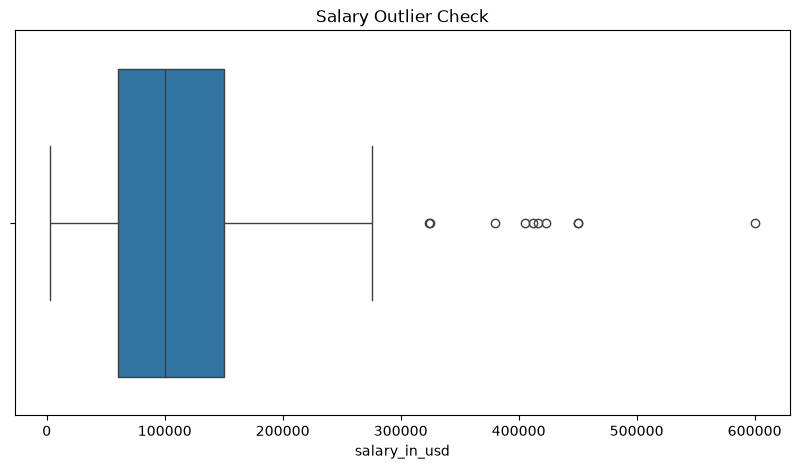

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.boxplot(x=df["salary_in_usd"])
plt.title("Salary Outlier Check")
plt.show()

In [56]:
df_no_high_outliers = df[df["salary_in_usd"] <= 300000].copy()

print(f"Original dataset shape: {df.shape}")
print(f"No high outliers dataset shape: {df_no_high_outliers.shape}")
print(f"Rows removed: {df.shape[0] - df_no_high_outliers.shape[0]}")

Original dataset shape: (565, 9)
No high outliers dataset shape: (555, 9)
Rows removed: 10


In [57]:
def train_and_evaluate_linear_model(data, model_name):
    X = data.drop(columns=["salary_in_usd"])
    y = data["salary_in_usd"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_columns),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
        ],
        remainder="drop"
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LinearRegression())
        ]
    )

    model.fit(X_train, y_train)

    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    train_mse = mean_squared_error(y_train, train_predictions)
    test_mse = mean_squared_error(y_test, test_predictions)

    return {
        "Model": model_name,
        "Rows": data.shape[0],
        "Train MAE": mean_absolute_error(y_train, train_predictions),
        "Test MAE": mean_absolute_error(y_test, test_predictions),
        "Train RMSE": np.sqrt(train_mse),
        "Test RMSE": np.sqrt(test_mse),
        "Train R2": r2_score(y_train, train_predictions),
        "Test R2": r2_score(y_test, test_predictions),
        "R2 Gap": r2_score(y_train, train_predictions) - r2_score(y_test, test_predictions)
    }

In [58]:
comparison_results = pd.DataFrame([
    train_and_evaluate_linear_model(df, "Original Linear Regression"),
    train_and_evaluate_linear_model(df_no_high_outliers, "No High Outliers Linear Regression")
])

comparison_results

,Model,Rows,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,R2 Gap
0,Original Linear Regression,565,24961.058954,33032.490493,37578.851326,55538.878159,0.734387,0.357899,0.376488
1,No High Outliers Linear Regression,555,21413.020420,29943.167451,30370.567424,39823.887905,0.737044,0.523931,0.213113


## Outlier Handling Observation

The original model had very high salary rows above 300000 USD.

After removing high salary outliers, I compared the model again using MAE, RMSE, R2, and R2 Gap.

If Test MAE and Test RMSE decrease, the model makes smaller salary errors.

If Test R2 increases, the model explains unseen test data better.

If R2 Gap decreases, the model is overfitting less.

High salary outliers above 300000 were hurting the model.
Removing them improved Test R2 and reduced RMSE strongly.
Removing low salary rows did not improve the model further, so I will not remove them for now.

The model improved, but the gap was still a bit high, so I needed to check rare categories next.


In [59]:
for column in categorical_columns:
    print(f"\nColumn: {column}")
    print(f"Unique values: {df_no_high_outliers[column].nunique()}")
    display(df_no_high_outliers[column].value_counts().head(20))
    display(df_no_high_outliers[column].value_counts().tail(20))


Column: experience_level
Unique values: 4


experience_level
SE    240
MI    205
EN     88
EX     22
Name: count, dtype: int64

experience_level
SE    240
MI    205
EN     88
EX     22
Name: count, dtype: int64


Column: employment_type
Unique values: 4


employment_type
FT    537
PT     10
CT      4
FL      4
Name: count, dtype: int64

employment_type
FT    537
PT     10
CT      4
FL      4
Name: count, dtype: int64


Column: job_title
Unique values: 49


job_title
Data Scientist                129
Data Engineer                 120
Data Analyst                   82
Machine Learning Engineer      39
Research Scientist             15
Data Science Manager           12
Data Architect                 11
Machine Learning Scientist      8
Big Data Engineer               8
Data Science Consultant         7
AI Scientist                    7
Data Analytics Manager          7
Lead Data Engineer              6
BI Data Analyst                 6
ML Engineer                     6
Computer Vision Engineer        6
Principal Data Scientist        6
Director of Data Science        6
Business Data Analyst           5
Data Engineering Manager        5
Name: count, dtype: int64

job_title
Data Science Engineer                 3
Machine Learning Developer            3
Applied Machine Learning Scientist    3
Product Data Analyst                  2
Cloud Data Engineer                   2
Director of Data Engineering          2
Principal Data Engineer               2
Principal Data Analyst                2
Machine Learning Manager              1
3D Computer Vision Researcher         1
Marketing Data Analyst                1
Data Specialist                       1
Finance Data Analyst                  1
Big Data Architect                    1
Staff Data Scientist                  1
ETL Developer                         1
Head of Machine Learning              1
NLP Engineer                          1
Lead Machine Learning Engineer        1
Financial Data Analyst                1
Name: count, dtype: int64


Column: employee_residence
Unique values: 57


employee_residence
US    285
GB     43
IN     30
CA     27
DE     24
FR     18
ES     15
GR     12
JP      7
PK      6
PT      6
BR      6
NL      5
PL      4
RU      4
IT      4
AE      3
AT      3
VN      3
TR      3
Name: count, dtype: int64

employee_residence
MT    1
CL    1
IR    1
CO    1
MD    1
KE    1
HK    1
RS    1
PR    1
LU    1
JE    1
CZ    1
AR    1
DZ    1
TN    1
MY    1
EE    1
BO    1
IE    1
CH    1
Name: count, dtype: int64


Column: company_location
Unique values: 50


company_location
US    308
GB     46
CA     28
DE     27
IN     24
FR     15
ES     14
GR     10
JP      6
NL      4
AT      4
PT      4
PL      4
PK      3
AE      3
MX      3
DK      3
LU      3
BR      3
TR      3
Name: count, dtype: int64

company_location
HU    1
NZ    1
HR    1
SG    1
RO    1
IQ    1
UA    1
IL    1
MT    1
CL    1
IR    1
CO    1
MD    1
KE    1
VN    1
AS    1
DZ    1
EE    1
MY    1
IE    1
Name: count, dtype: int64


Column: company_size
Unique values: 3


company_size
M    288
L    186
S     81
Name: count, dtype: int64

company_size
M    288
L    186
S     81
Name: count, dtype: int64


# Observation:
company_size contains only three categories (M, L, S).

All categories have sufficient observations:
M = 288
L = 186
S = 81

I do not see a rare category issue here.

So I do not need to group `company_size`.


`company_size
    ✓ No action needed

company_location
    ⚠ Needs rare-category analysis

employee_residence
    ⚠ Check next

job_title
    ⚠ Most likely biggest source of rare categories`

# Analyzing Remaining Categorical Columns For Low-Frequency Categories


In [60]:
# Analyzingremaining categorical columns for low-frequency categories

for column in categorical_columns:
    counts = df_no_high_outliers[column].value_counts()

    rare_count = (counts < 5).sum()

    print(f"\n{column}")
    print(f"Unique Categories: {df_no_high_outliers[column].nunique()}")
    print(f"Rare Categories (<5 rows): {rare_count}")
    for column in categorical_columns:
        print(f"\n{column}")
        print(df_no_high_outliers[column].value_counts().tail(20))


experience_level
Unique Categories: 4
Rare Categories (<5 rows): 0

experience_level
experience_level
SE    240
MI    205
EN     88
EX     22
Name: count, dtype: int64

employment_type
employment_type
FT    537
PT     10
CT      4
FL      4
Name: count, dtype: int64

job_title
job_title
Data Science Engineer                 3
Machine Learning Developer            3
Applied Machine Learning Scientist    3
Product Data Analyst                  2
Cloud Data Engineer                   2
Director of Data Engineering          2
Principal Data Engineer               2
Principal Data Analyst                2
Machine Learning Manager              1
3D Computer Vision Researcher         1
Marketing Data Analyst                1
Data Specialist                       1
Finance Data Analyst                  1
Big Data Architect                    1
Staff Data Scientist                  1
ETL Developer                         1
Head of Machine Learning              1
NLP Engineer                   

# Create A Grouped Dataset And Compare It Against My Current Best Model

Here I group rare categories into `Other` so the model does not overfit to categories that appear only a few times.

In [61]:
rare_category_columns = [
    "job_title",
    "employee_residence",
    "company_location"
]

rare_threshold = 5

df_grouped_rare_categories = df_no_high_outliers.copy()

for column in rare_category_columns:
    category_counts = df_grouped_rare_categories[column].value_counts()
    rare_categories = category_counts[category_counts < rare_threshold].index

    df_grouped_rare_categories[column] = df_grouped_rare_categories[column].where(
        ~df_grouped_rare_categories[column].isin(rare_categories),
        "Other"
    )

    print(f"{column}")
    print(f"Rare categories grouped: {len(rare_categories)}")
    print(f"Unique values after grouping: {df_grouped_rare_categories[column].nunique()}")
    print()

job_title
Rare categories grouped: 28
Unique values after grouping: 22

employee_residence
Rare categories grouped: 44
Unique values after grouping: 14

company_location
Rare categories grouped: 41
Unique values after grouping: 10



In [62]:
for column in rare_category_columns:
    print(f"\nColumn: {column}")
    display(df_grouped_rare_categories[column].value_counts().head(20))


Column: job_title


job_title
Data Scientist                129
Data Engineer                 120
Data Analyst                   82
Other                          59
Machine Learning Engineer      39
Research Scientist             15
Data Science Manager           12
Data Architect                 11
Machine Learning Scientist      8
Big Data Engineer               8
Data Science Consultant         7
AI Scientist                    7
Data Analytics Manager          7
Lead Data Engineer              6
BI Data Analyst                 6
ML Engineer                     6
Computer Vision Engineer        6
Principal Data Scientist        6
Director of Data Science        6
Business Data Analyst           5
Name: count, dtype: int64


Column: employee_residence


employee_residence
US       285
Other     71
GB        43
IN        30
CA        27
DE        24
FR        18
ES        15
GR        12
JP         7
PK         6
PT         6
BR         6
NL         5
Name: count, dtype: int64


Column: company_location


company_location
US       308
Other     77
GB        46
CA        28
DE        27
IN        24
FR        15
ES        14
GR        10
JP         6
Name: count, dtype: int64

In [63]:
comparison_results = pd.DataFrame([
    train_and_evaluate_linear_model(df, "Original Linear Regression"),
    train_and_evaluate_linear_model(df_no_high_outliers, "No High Outliers Linear Regression"),
    train_and_evaluate_linear_model(df_grouped_rare_categories, "No High Outliers + Rare Grouping")
])

comparison_results

,Model,Rows,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,R2 Gap
0,Original Linear Regression,565,24961.058954,33032.490493,37578.851326,55538.878159,0.734387,0.357899,0.376488
1,No High Outliers Linear Regression,555,21413.020420,29943.167451,30370.567424,39823.887905,0.737044,0.523931,0.213113
2,No High Outliers + Rare Grouping,555,26045.923947,28009.324467,33977.429430,37655.200673,0.670877,0.574370,0.096507


## 16. Try Ridge Regression

Ridge Regression is still a linear model, but it adds regularization.

Regularization penalizes very large coefficients, which helps when one-hot encoding creates many features.

I use the current best dataset here: `df_grouped_rare_categories`.

In [64]:
def train_and_evaluate_model(data, model, model_name):
    X = data.drop(columns=["salary_in_usd"])
    y = data["salary_in_usd"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_columns),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
        ],
        remainder="drop"
    )

    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    model_pipeline.fit(X_train, y_train)

    train_predictions = model_pipeline.predict(X_train)
    test_predictions = model_pipeline.predict(X_test)

    train_mse = mean_squared_error(y_train, train_predictions)
    test_mse = mean_squared_error(y_test, test_predictions)

    train_r2 = r2_score(y_train, train_predictions)
    test_r2 = r2_score(y_test, test_predictions)

    return {
        "Model": model_name,
        "Rows": data.shape[0],
        "Train MAE": mean_absolute_error(y_train, train_predictions),
        "Test MAE": mean_absolute_error(y_test, test_predictions),
        "Train RMSE": np.sqrt(train_mse),
        "Test RMSE": np.sqrt(test_mse),
        "Train R2": train_r2,
        "Test R2": test_r2,
        "R2 Gap": train_r2 - test_r2
    }

## 17. Compare Ridge Alpha Values

`alpha` controls regularization strength.

- Smaller alpha: closer to normal Linear Regression
- Larger alpha: stronger penalty on large coefficients

The best alpha should improve test metrics without making the model too weak.

In [65]:
ridge_results = pd.DataFrame([
    train_and_evaluate_model(
        df_grouped_rare_categories,
        LinearRegression(),
        "Linear Regression - Grouped Data"
    ),
    train_and_evaluate_model(
        df_grouped_rare_categories,
        Ridge(alpha=0.1),
        "Ridge alpha=0.1"
    ),
    train_and_evaluate_model(
        df_grouped_rare_categories,
        Ridge(alpha=1.0),
        "Ridge alpha=1.0"
    ),
    train_and_evaluate_model(
        df_grouped_rare_categories,
        Ridge(alpha=10.0),
        "Ridge alpha=10.0"
    ),
    train_and_evaluate_model(
        df_grouped_rare_categories,
        Ridge(alpha=100.0),
        "Ridge alpha=100.0"
    )
])

ridge_results.sort_values("Test RMSE")

,Model,Rows,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,R2 Gap
3,Ridge alpha=10.0,555,27034.089737,28332.952840,35666.718897,37239.287126,0.637337,0.583720,0.053617
2,Ridge alpha=1.0,555,26127.579426,27921.397350,34116.878289,37246.932554,0.668170,0.583549,0.084621
1,Ridge alpha=0.1,555,26059.403029,27950.599656,33981.975324,37562.878115,0.670789,0.576454,0.094335
0,Linear Regression - Grouped Data,555,26045.923947,28009.324467,33977.429430,37655.200673,0.670877,0.574370,0.096507
4,Ridge alpha=100.0,555,32168.939893,31811.440983,41662.595889,41895.347112,0.505154,0.473117,0.032037


## Ridge Decision Rule

Choose the Ridge model if it improves test performance or reduces overfitting without hurting error too much.

Main checks:

- Lower Test MAE is better
- Lower Test RMSE is better
- Higher Test R2 is better
- Lower R2 Gap means less overfitting

## 18. Select Best Model

I select the best model using `Test RMSE` because RMSE penalizes large salary mistakes more strongly than MAE.

Lower `Test RMSE` means fewer large prediction errors on unseen data.

In [66]:
best_model_name = "Ridge Regression alpha=10"

best_model_summary = ridge_results.sort_values("Test RMSE").head(1)

best_model_summary

,Model,Rows,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,R2 Gap
3,Ridge alpha=10.0,555,27034.089737,28332.95284,35666.718897,37239.287126,0.637337,0.58372,0.053617


## 19. Train Final Best Model

The final model uses the best dataset and best algorithm found in this notebook:

- High salary outliers above 300000 removed
- Rare categories grouped into `Other`
- Ridge Regression with `alpha=10`

In [67]:
final_X = df_grouped_rare_categories.drop(columns=["salary_in_usd"])
final_y = df_grouped_rare_categories["salary_in_usd"]

final_X_train, final_X_test, final_y_train, final_y_test = train_test_split(
    final_X,
    final_y,
    test_size=0.2,
    random_state=42
)

final_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ],
    remainder="drop"
)

final_model = Pipeline(
    steps=[
        ("preprocessor", final_preprocessor),
        ("model", Ridge(alpha=10.0))
    ]
)

final_model.fit(final_X_train, final_y_train)

print("Final Ridge model trained successfully.")

Final Ridge model trained successfully.


## 20. Evaluate Final Model

I evaluate the final model on train and test data one last time.

In [68]:
final_train_predictions = final_model.predict(final_X_train)
final_test_predictions = final_model.predict(final_X_test)

final_train_mse = mean_squared_error(final_y_train, final_train_predictions)
final_test_mse = mean_squared_error(final_y_test, final_test_predictions)

final_metrics = pd.DataFrame([
    {
        "Dataset": "Train",
        "MAE": mean_absolute_error(final_y_train, final_train_predictions),
        "RMSE": np.sqrt(final_train_mse),
        "R2": r2_score(final_y_train, final_train_predictions)
    },
    {
        "Dataset": "Test",
        "MAE": mean_absolute_error(final_y_test, final_test_predictions),
        "RMSE": np.sqrt(final_test_mse),
        "R2": r2_score(final_y_test, final_test_predictions)
    }
])

final_metrics

,Dataset,MAE,RMSE,R2
0,Train,27034.089737,35666.718897,0.637337
1,Test,28332.952840,37239.287126,0.583720


## 21. Final Error Analysis

Even improved models make mistakes. This table shows the largest remaining errors.

In [69]:
final_error_analysis = final_X_test.copy()

final_error_analysis["Actual"] = final_y_test
final_error_analysis["Predicted"] = final_test_predictions
final_error_analysis["Error"] = final_error_analysis["Actual"] - final_error_analysis["Predicted"]
final_error_analysis["Absolute_Error"] = final_error_analysis["Error"].abs()

final_error_analysis.sort_values("Absolute_Error", ascending=False).head(15)

,work_year,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size,Actual,Predicted,Error,Absolute_Error
78,2021,MI,CT,ML Engineer,US,100,US,L,270000,120552.809154,149447.190846,149447.190846
93,2021,SE,FT,Lead Data Engineer,US,0,US,L,276000,159447.580240,116552.419760,116552.419760
536,2022,SE,FT,Data Engineer,US,0,US,M,54000,148130.550610,-94130.550610,94130.550610
332,2022,SE,FT,Data Engineer,US,100,US,M,243900,150450.605491,93449.394509,93449.394509
141,2021,SE,FT,Data Science Manager,US,0,US,L,240000,163424.437125,76575.562875,76575.562875
409,2022,SE,FT,Data Scientist,US,0,US,M,80000,152599.318167,-72599.318167,72599.318167
149,2021,SE,FT,Other,BR,100,US,S,160000,90443.657205,69556.342795,69556.342795
113,2021,EN,PT,AI Scientist,PK,100,US,M,12000,69661.689497,-57661.689497,57661.689497
182,2021,MI,FT,Data Engineer,Other,0,US,L,26005,81136.124399,-55131.124399,55131.124399
9,2020,SE,FT,Lead Data Engineer,Other,50,Other,S,125000,70475.705780,54524.294220,54524.294220


## 22. Compare Original vs Final Model

This table combines the baseline, preprocessing improvements, and Ridge experiments.

In [70]:
final_comparison = pd.concat([
    comparison_results,
    ridge_results
], ignore_index=True)

final_comparison.sort_values("Test RMSE")

,Model,Rows,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,R2 Gap
6,Ridge alpha=10.0,555,27034.089737,28332.952840,35666.718897,37239.287126,0.637337,0.583720,0.053617
5,Ridge alpha=1.0,555,26127.579426,27921.397350,34116.878289,37246.932554,0.668170,0.583549,0.084621
4,Ridge alpha=0.1,555,26059.403029,27950.599656,33981.975324,37562.878115,0.670789,0.576454,0.094335
3,Linear Regression - Grouped Data,555,26045.923947,28009.324467,33977.429430,37655.200673,0.670877,0.574370,0.096507
2,No High Outliers + Rare Grouping,555,26045.923947,28009.324467,33977.429430,37655.200673,0.670877,0.574370,0.096507
1,No High Outliers Linear Regression,555,21413.020420,29943.167451,30370.567424,39823.887905,0.737044,0.523931,0.213113
7,Ridge alpha=100.0,555,32168.939893,31811.440983,41662.595889,41895.347112,0.505154,0.473117,0.032037
0,Original Linear Regression,565,24961.058954,33032.490493,37578.851326,55538.878159,0.734387,0.357899,0.376488


## Final Model Improvement Summary

The original Linear Regression model overfit the training data.

Original model:

- Test R2 was low
- R2 Gap was high
- RMSE was high because extreme salary values affected the model

Improvements made:

1. Removed high salary outliers above 300000 USD.
2. Grouped rare `job_title`, `employee_residence`, and `company_location` values into `Other`.
3. Replaced plain Linear Regression with Ridge Regression.

Best model:

- Ridge Regression with `alpha=10`
- Dataset used: high outliers removed + rare categories grouped

Why this model is better:

- Test RMSE decreased
- Test R2 increased
- R2 Gap decreased
- The model generalizes better to unseen data

Important note:

This model is improved, but not perfect. Salary prediction is difficult because salary depends on many missing real-world factors such as exact years of experience, company, skills, negotiation, market condition, and job level.